In [1]:
# Import all necessary libraries
import numpy as np 
import random
import matplotlib.pyplot as plt
import math
import pickle
import os
import pandas as pd
import random
plt.rcParams['figure.figsize'] = [10, 7]
#import mpl_scatter_density # adds projection='scatter_density'

import gc
import BigMetaTableLibrary as BMT
from EmulatorLibrary import *

{'System_main': {'Pressure': 0, 'Temperature': 1, 'logfO2-QFM': 2, 'viscosity': 90, 'H': 91, 'Cp': 92}, 'olivine': {'mass (gm)': 3, 'tephroite': 4, 'fayalite': 5, 'ni-olivine': 6, 'monticellite': 7, 'forsterite': 8, 'rho (gm/cc)': 93, 'H (kJ)': 94}, 'orthopyroxene': {'mass (gm)': 9, 'diopside': 10, 'clinoenstatite': 11, 'hedenbergite': 12, 'alumino-buffonite': 13, 'buffonite': 14, 'essenite': 15, 'jadeite': 16, 'rho (gm/cc)': 95, 'H (kJ)': 96}, 'clinopyroxene': {'mass (gm)': 17, 'diopside': 18, 'clinoenstatite': 19, 'hedenbergite': 20, 'alumino-buffonite': 21, 'buffonite': 22, 'essenite': 23, 'jadeite': 24, 'rho (gm/cc)': 97, 'H (kJ)': 98}, 'spinel': {'mass (gm)': 25, 'chromite': 26, 'hercynite': 27, 'magnetite': 28, 'spinel': 29, 'ulvospinel': 30, 'rho (gm/cc)': 99, 'H (kJ)': 100}, 'plagioclase': {'mass (gm)': 31, 'albite': 32, 'anorthite': 33, 'highsanidine': 34, 'rho (gm/cc)': 101, 'H (kJ)': 102}, 'alkali-feldspar': {'mass (gm)': 35, 'albite': 36, 'anorthite': 37, 'sanidine': 38, 'r

In [2]:
"""Define all labeling systems / dictionaries for this module"""

# Old Filters for deep_filter function
Oxide_Lower_Bounds = [['melts-liquid', 'SiO2', 37],
                      ['nepheline', 'Na2O', 12.5],
                      ['garnet', 'FeO', 5],
                      ['k-feldspar', 'K2O', 8],
                      ['clinopyroxene', 'CaO', 7],
                      ['orthopyroxene', 'MgO', 13]]

easy_build_oxide_upper_bounds = {'melts-liquid': [ ['NiO', 1], ['MgO', 50], ['TiO2', 6], ['MnO', 1]],
                                 'rhm-oxide': [['MnO', 7]],
                                 'nepheline': [['K2O', 11]],
                                 'k-feldspar': [['CaO', 1]],
                                 'plagioclase': [['K2O', 3]],
                                 'clinopyroxene': [ ['TiO2', 6], ['Al2O3', 13], ['Na2O', 4], ['Fe2O3', 3] ],
                                 'orthopyroxene': [ ['TiO2', 2], ['Al2O3', 7], ['Na2O', 0.2], ['Fe2O3', 3], ['CaO', 4] ],
                                 'olivine': [ ['CaO', 0.6], ['NiO', 2], ['MnO', 1] ]
                                }
                                      
Oxide_Upper_Bounds = []

for phase, boundlist in easy_build_oxide_upper_bounds.items():
    for ox, bound in boundlist:
        Oxide_Upper_Bounds.append([phase, ox, bound])
print(Oxide_Upper_Bounds)    

[['melts-liquid', 'NiO', 1], ['melts-liquid', 'MgO', 50], ['melts-liquid', 'TiO2', 6], ['melts-liquid', 'MnO', 1], ['rhm-oxide', 'MnO', 7], ['nepheline', 'K2O', 11], ['k-feldspar', 'CaO', 1], ['plagioclase', 'K2O', 3], ['clinopyroxene', 'TiO2', 6], ['clinopyroxene', 'Al2O3', 13], ['clinopyroxene', 'Na2O', 4], ['clinopyroxene', 'Fe2O3', 3], ['orthopyroxene', 'TiO2', 2], ['orthopyroxene', 'Al2O3', 7], ['orthopyroxene', 'Na2O', 0.2], ['orthopyroxene', 'Fe2O3', 3], ['orthopyroxene', 'CaO', 4], ['olivine', 'CaO', 0.6], ['olivine', 'NiO', 2], ['olivine', 'MnO', 1]]


In [ ]:
# Batch Melting data processing workflow

ValidName = "MELTS_ValidsetSept25BatchCooling_subset"
TestName = "MELTS_TestsetSept25BatchCooling_subset"
TrainName = 'MELTS_TrainsetSept25BatchCooling_subset'

#time.sleep(3600) #1 Hour Sleep

Oxide_Lower_Bounds = [['k-feldspar', 'K2O', 8],
                      ['clinopyroxene', 'CaO', 7]]

easy_build_oxide_upper_bounds = {'k-feldspar': [['CaO', 1]],
                                 'plagioclase': [['K2O', 8]],
                                 'clinopyroxene': [ ['TiO2', 6], ['Al2O3', 8] ],
                                 'orthopyroxene': [ ['TiO2', 2], ['Al2O3', 8], ['CaO', 4] ],
                                }
                                      
Oxide_Upper_Bounds = []

for phase, boundlist in easy_build_oxide_upper_bounds.items():
    for ox, bound in boundlist:
        Oxide_Upper_Bounds.append([phase, ox, bound])
print(Oxide_Upper_Bounds)    

Component_Upper_Bounds = [ ['plagioclase', 'highsanidine', 0.1] ]


gc.collect()
TrainMELTS = BMT.BigMetaTable(TrainName)
TrainMELTS.separate_analcime()
# Subsampling breaks continuity neecsary to blur phase boundaries
#TrainMELTS.filter_all(generate_binaries=True, thresholds = np.array([6,12,4,4,4,5,10]))
TrainMELTS.filter_full_metadata()
TrainMELTS.filter_legal()


TrainMELTS.filename = f"{TrainName}Filtered"
TrainMELTS.resample_rare_phase(component_indices['nepheline']['mass (gm)'], multiplier_bounds = (0.8,1.1), n_resamples=10, overwrite=True)
TrainMELTS.resample_rare_phase(component_indices['leucite']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=2, overwrite=True)
TrainMELTS.resample_rare_phase(component_indices['analcime']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=3, overwrite=True)
TrainMELTS.resample_rare_phase(component_indices['olivine']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=1, overwrite=True)
TrainMELTS.resample_rare_phase(component_indices['muscovite']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=3, overwrite=True)
TrainMELTS.resample_rare_phase(component_indices['biotite']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=1, overwrite=True)
TrainMELTS.resample_rare_phase(component_indices['k-feldspar']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=1, overwrite=True)


BMT.balance_lowF(TrainMELTS)

TrainMELTS.filename = f'{TrainName}Intensive'

BMT.resampling_to_datasets(TrainMELTS,[[1,1],[.8,1],[0.5,1]])
BMT.deep_filter(f'{TrainName}Intensive', Oxide_Lower_Bounds=Oxide_Lower_Bounds, 
            Oxide_Upper_Bounds=Oxide_Upper_Bounds, Component_Upper_Bounds=Component_Upper_Bounds)


#train_plot_directory = 'Training_Dataset_July28Intensive'

#BMT.make_harkers(TrainMELTS, train_plot_directory+'/')
#BMT.make_Tplots(TrainMELTS, train_plot_directory+'/') 
#BMT.F_phase_plots(partition_directory=train_plot_directory, filename=TrainMELTS.filename)

del TrainMELTS.table
del TrainMELTS
gc.collect()

ValidMELTS = BMT.BigMetaTable(ValidName)
ValidMELTS.separate_analcime()
#ValidMELTS.filter_all(generate_binaries=True, thresholds = np.array([6,12,4,4,4,5,10]))
ValidMELTS.filter_full_metadata()
ValidMELTS.filter_legal()
ValidMELTS, TestMELTS = ValidMELTS.split(0.15)



TestMELTS.filename = f"{TestName}Filtered"
TestMELTS.resample_rare_phase(component_indices['nepheline']['mass (gm)'], multiplier_bounds = (0.99,1.01), n_resamples=10, overwrite=True)
TestMELTS.resample_rare_phase(component_indices['leucite']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=2, overwrite =True)
TestMELTS.resample_rare_phase(component_indices['analcime']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=3, overwrite =True)
TestMELTS.resample_rare_phase(component_indices['olivine']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=1, overwrite =True)
TestMELTS.resample_rare_phase(component_indices['muscovite']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=3, overwrite =True)
TestMELTS.resample_rare_phase(component_indices['biotite']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=1, overwrite =True)
TestMELTS.resample_rare_phase(component_indices['k-feldspar']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=1, overwrite =True)

print("################ After resampling ####################")

BMT.balance_lowF(TestMELTS)
BMT.balance_lowF(ValidMELTS)

TestMELTS.filename = f'{TestName}Intensive'
ValidMELTS.filename = f'{ValidName}Intensive'

BMT.resampling_to_datasets(TestMELTS)
BMT.resampling_to_datasets(ValidMELTS)

BMT.deep_filter(f'{TestName}Intensive', Oxide_Lower_Bounds=Oxide_Lower_Bounds, 
            Oxide_Upper_Bounds=Oxide_Upper_Bounds, Component_Upper_Bounds=Component_Upper_Bounds)
BMT.deep_filter(f'{ValidName}Intensive', Oxide_Lower_Bounds=Oxide_Lower_Bounds, 
            Oxide_Upper_Bounds=Oxide_Upper_Bounds, Component_Upper_Bounds=Component_Upper_Bounds)

valid_plot_directory = f"{ValidName}Plots"

BMT.make_harkers(ValidMELTS, valid_plot_directory+'/')
BMT.make_Tplots(ValidMELTS, valid_plot_directory+'/') 
#BMT.F_phase_plots(partition_directory=valid_plot_directory, filename=ValidMELTS.filename)

del TestMELTS.table, ValidMELTS.table
del TestMELTS, ValidMELTS
gc.collect()

In [2]:
# Fraction Crystalization  data processing workflow

TrainName = '102Datasets/MELTS_TrainsetSept25FxtalCooling_subset'
ValidName = "102Datasets/MELTS_ValidsetSept25FxtalCooling_subset"
TestName = "102Datasets/MELTS_TestsetSept25FxtalCooling_subset"

#time.sleep(3600) #1 Hour Sleep

Oxide_Lower_Bounds = [['k-feldspar', 'K2O', 8],
                      ['clinopyroxene', 'CaO', 7]]

easy_build_oxide_upper_bounds = {'k-feldspar': [['CaO', 1]],
                                 'plagioclase': [['K2O', 8]],
                                 'clinopyroxene': [ ['TiO2', 6], ['Al2O3', 8] ],
                                 'orthopyroxene': [ ['TiO2', 2], ['Al2O3', 8], ['CaO', 4] ],
                                }
                                      
Oxide_Upper_Bounds = []

for phase, boundlist in easy_build_oxide_upper_bounds.items():
    for ox, bound in boundlist:
        Oxide_Upper_Bounds.append([phase, ox, bound])
print(Oxide_Upper_Bounds)    

Component_Upper_Bounds = [ ['plagioclase', 'highsanidine', 0.1] ]


gc.collect()
TrainMELTS = BMT.BigMetaTable(TrainName)
TrainMELTS.separate_analcime()
# Subsampling breaks continuity neecsary to blur phase boundaries
#TrainMELTS.filter_all(generate_binaries=True, thresholds = np.array([6,12,4,4,4,5,10]))
TrainMELTS.filter_full_metadata()
TrainMELTS.filter_legal()


TrainMELTS.filename = f"{TrainName}Filtered"
TrainMELTS.resample_rare_phase(component_indices['nepheline']['mass (gm)'], multiplier_bounds = (0.8,1.1), n_resamples=10, overwrite=False)
TrainMELTS.resample_rare_phase(component_indices['leucite']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=2, overwrite=True)
TrainMELTS.resample_rare_phase(component_indices['analcime']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=3, overwrite=True)
TrainMELTS.resample_rare_phase(component_indices['olivine']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=1, overwrite=True)
TrainMELTS.resample_rare_phase(component_indices['muscovite']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=3, overwrite=True)
TrainMELTS.resample_rare_phase(component_indices['biotite']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=1, overwrite=True)
TrainMELTS.resample_rare_phase(component_indices['k-feldspar']['mass (gm)'], multiplier_bounds=(0.8,1.1), n_resamples=1, overwrite=True)


BMT.balance_Superliquidus_fxtal(TrainMELTS)

TrainMELTS.filename = f'{TrainName}Intensive'

BMT.resampling_to_datasets(TrainMELTS,[[1,1],[.8,1],[0.5,1]])
BMT.deep_filter(f'{TrainName}Intensive', Oxide_Lower_Bounds=Oxide_Lower_Bounds, 
            Oxide_Upper_Bounds=Oxide_Upper_Bounds, Component_Upper_Bounds=Component_Upper_Bounds)


#train_plot_directory = 'Training_Dataset_July28Intensive'

#BMT.make_harkers(TrainMELTS, train_plot_directory+'/')
#BMT.make_Tplots(TrainMELTS, train_plot_directory+'/') 
#BMT.F_phase_plots(partition_directory=train_plot_directory, filename=TrainMELTS.filename)

del TrainMELTS.table
del TrainMELTS
gc.collect()

ValidMELTS = BMT.BigMetaTable(ValidName)
ValidMELTS.separate_analcime()
#ValidMELTS.filter_all(generate_binaries=True, thresholds = np.array([6,12,4,4,4,5,10]))
ValidMELTS.filter_full_metadata()
ValidMELTS.filter_legal()
ValidMELTS, TestMELTS = ValidMELTS.split(0.15)



TestMELTS.filename = f"{TestName}Filtered"
TestMELTS.resample_rare_phase(component_indices['nepheline']['mass (gm)'], multiplier_bounds = (0.99,1.01), n_resamples=10, overwrite=False)
TestMELTS.resample_rare_phase(component_indices['leucite']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=2, overwrite =True)
TestMELTS.resample_rare_phase(component_indices['analcime']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=3, overwrite =True)
TestMELTS.resample_rare_phase(component_indices['olivine']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=1, overwrite =True)
TestMELTS.resample_rare_phase(component_indices['muscovite']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=3, overwrite =True)
TestMELTS.resample_rare_phase(component_indices['biotite']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=1, overwrite =True)
TestMELTS.resample_rare_phase(component_indices['k-feldspar']['mass (gm)'], multiplier_bounds=(0.99,1.01), n_resamples=1, overwrite =True)

print("################ After resampling ####################")

BMT.balance_Superliquidus_fxtal(TestMELTS)
BMT.balance_Superliquidus_fxtal(ValidMELTS)

TestMELTS.filename = f'{TestName}Intensive'
ValidMELTS.filename = f'{ValidName}Intensive'

BMT.resampling_to_datasets(TestMELTS)
BMT.resampling_to_datasets(ValidMELTS)

BMT.deep_filter(f'{TestName}Intensive', Oxide_Lower_Bounds=Oxide_Lower_Bounds, 
            Oxide_Upper_Bounds=Oxide_Upper_Bounds, Component_Upper_Bounds=Component_Upper_Bounds)
BMT.deep_filter(f'{ValidName}Intensive', Oxide_Lower_Bounds=Oxide_Lower_Bounds, 
            Oxide_Upper_Bounds=Oxide_Upper_Bounds, Component_Upper_Bounds=Component_Upper_Bounds)

valid_plot_directory = f"{ValidName}Plots"

BMT.make_harkers(ValidMELTS, valid_plot_directory+'/')
BMT.make_Tplots(ValidMELTS, valid_plot_directory+'/') 
#BMT.F_phase_plots(partition_directory=valid_plot_directory, filename=ValidMELTS.filename)

del TestMELTS.table, ValidMELTS.table
del TestMELTS, ValidMELTS
gc.collect()

[['k-feldspar', 'CaO', 1], ['plagioclase', 'K2O', 8], ['clinopyroxene', 'TiO2', 6], ['clinopyroxene', 'Al2O3', 8], ['orthopyroxene', 'TiO2', 2], ['orthopyroxene', 'Al2O3', 8], ['orthopyroxene', 'CaO', 4]]
102Datasets/MELTS_TrainsetSept25FxtalCooling_subset.npy  DOES NOT EXIST
[INFO] Preparing to process 4000000 of 4000000 total rows with 138 columns...


[INFO] Loaded 4000000 valid rows into memmap
[TIMER] Completed in 244.19 seconds
Preparing to read 4000000 rows of text


Reading Text...: 100%|██████████| 4000000/4000000 [00:07<00:00, 536767.01it/s]


[TIMER] Parsed 4000000 of 4000000 Metadata to Lists: completed in 264.00 seconds
[TIMER] Metadata Lists to arrays: completed in 3.37 seconds
Total Length:4000000, Leucites: 21145, of which 8059 are analcime
Deleted 1934 for TiO2 dominant liquids
Deleted 0 for out-of-bounds fO2
Deleted 0 for having amphibole
Deleted 356 for low (<20%) SiO2 liquids
Target bin amount: 808776
1477469 of 2286245 will be deleted.
None to delete for balancing melt fraction
Deleting 1477469 entries
INITIALIZE


Generating Molar Features and Labels:   0%|          | 0/3 [00:00<?, ?it/s]

SAMPLE: 0


some error... closing memmaps


ValueError: operands could not be broadcast together with shapes (3287136,21) (3287136,20) (3287136,21) 

In [7]:
mass_phasedict['melts-liquid']

19

In [ ]:
"""
This block is used to create a smaller csv file out of very large initial ones. 
I Should work on building subsampling into the data generation itself
"""

valid_inds = BMT.collect_indices('MELTS_ValidsetSept25BatchCooling.csv', mass_indices=mass_indices, known_total_rows = None, batch_size=100000, maximum_indices = 1E6, random_state=None, has_header=True)
print('Making New csv and txt')
BMT.extract_rows('MELTS_ValidsetSept25BatchCooling', indices=valid_inds, new_suffix="_subset")
del valid_inds
gc.collect()

train_inds = BMT.collect_indices('MELTS_TrainsetSept25BatchCooling.csv', mass_indices=mass_indices, known_total_rows = None, batch_size=100000, maximum_indices = 4E6, random_state=None, has_header=True)
print('Making New csv and txt')
BMT.extract_rows('MELTS_TrainsetSept25BatchCooling', indices=train_inds, new_suffix="_subset")
del train_inds
gc.collect()

valid_inds = BMT.collect_indices('MELTS_ValidsetSept25FxtalCooling.csv', mass_indices=mass_indices, known_total_rows = None, batch_size=100000, maximum_indices = 1E6, random_state=None, has_header=True)
print('Making New csv and txt')
BMT.extract_rows('MELTS_ValidsetSept25FxtalCooling', indices=valid_inds, new_suffix="_subset")
print(len(valid_inds))
del valid_inds
gc.collect()

train_inds = BMT.collect_indices('MELTS_TrainsetSept25FxtalCooling.csv', mass_indices=mass_indices, known_total_rows = None, batch_size=100000, maximum_indices = 4E6, random_state=None, has_header=True)
print('Making New csv and txt')
BMT.extract_rows('MELTS_TrainsetSept25FxtalCooling', indices=train_inds, new_suffix="_subset")
del train_inds
gc.collect()

3027216 collected; reducing to 1000000.0
Making New csv and txt


11185222 collected; reducing to 4000000.0
Making New csv and txt


0

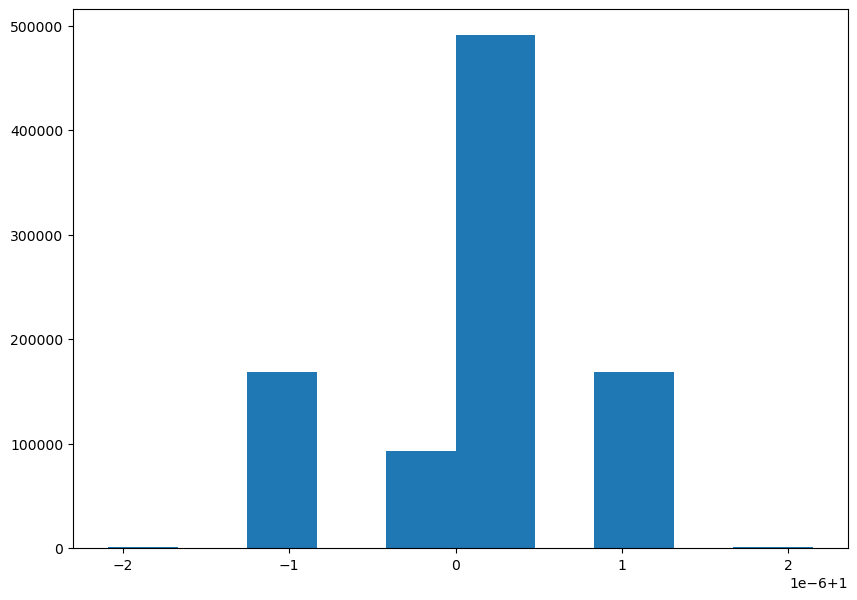

lr = 0.01
Step 0: Loss = 0.061666
lr = 0.01
Step 500: Loss = -0.000183
lr = 0.01
Step 1000: Loss = -0.000198
lr = 0.01
Step 1500: Loss = -0.000199
lr = 0.01
Step 2000: Loss = -0.000200
lr = 0.001
Step 2500: Loss = -0.000200
lr = 0.001
Step 3000: Loss = -0.000200
lr = 0.001
Step 3500: Loss = -0.000200
lr = 0.001
Step 4000: Loss = -0.000200
lr = 0.001
Step 4500: Loss = -0.000200
lr = 0.0001
Step 5000: Loss = -0.000200
lr = 0.0001
Step 5500: Loss = -0.000200
lr = 0.0001
Step 6000: Loss = -0.000200
lr = 0.0001
Step 6500: Loss = -0.000200
lr = 0.0001
Step 7000: Loss = -0.000200
lr = 1e-05
Step 7500: Loss = -0.000200
lr = 1e-05
Step 8000: Loss = -0.000200
lr = 1e-05
Step 8500: Loss = -0.000200
lr = 1e-05
Step 9000: Loss = -0.000200
lr = 1e-05
Step 9500: Loss = -0.000200
[[  1.00   0.00   0.00   0.00   0.00]
 [  0.00   1.00   0.00   0.00   0.00]
 [  0.00   0.40   0.60   0.00   0.00]
 [  0.00   0.95   0.00   0.05   0.00]
 [  0.00   0.28   0.00   0.00   0.72]]


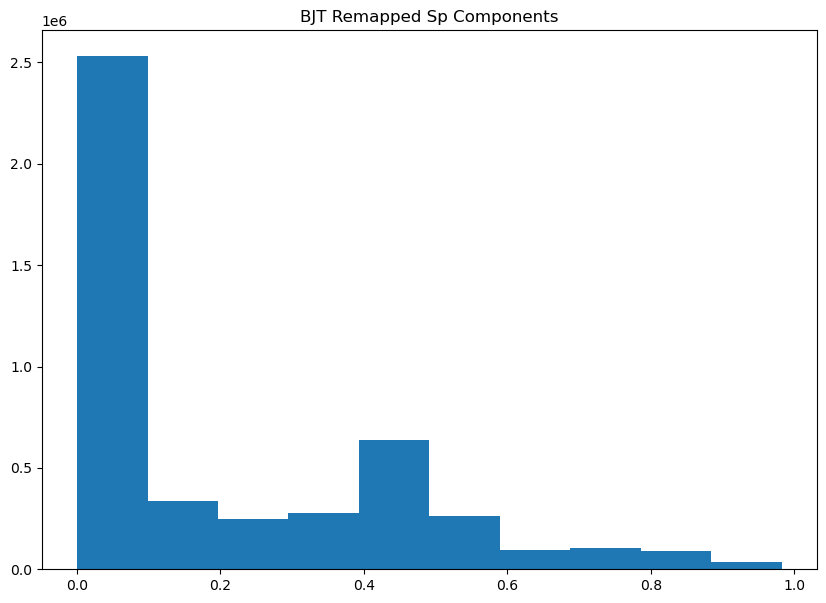

MINIMUM REMAP: 0.0, MAXIMUM: 0.9824732542037964


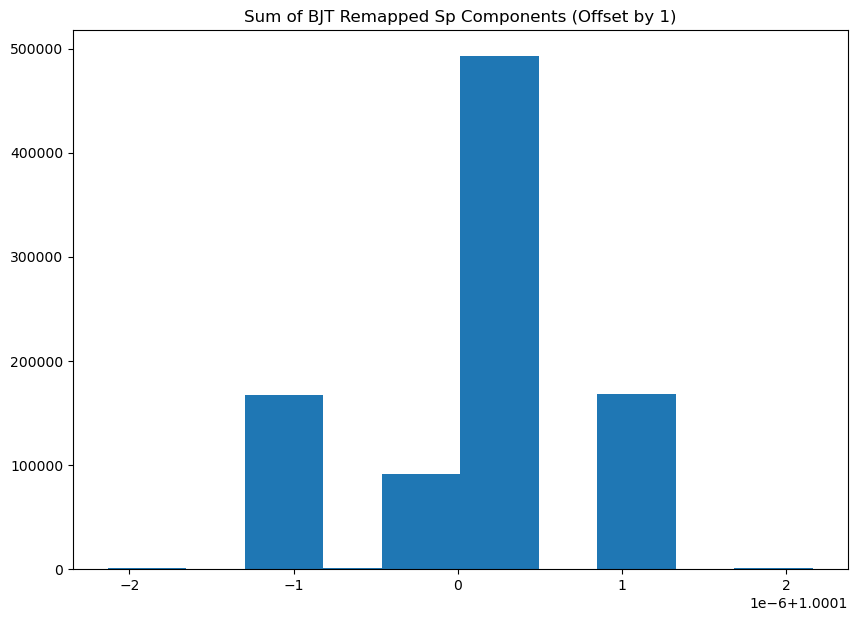

NameError: name 'px_components' is not defined

In [ ]:
"""
Spinel Solver. Gradient descent used to find invertible transformation matrix 
that makes all components positive
"""

#Big_table = BMT.BigMetaTable(...Put dataset here)

import torch
import torch.nn as nn
import torch.optim as optim

def solve_masked_A(x, mask=None, lr=0.01, steps=20000, leak=0.001, seed=0):
    """
    Solve for matrix A such that x @ A = g
    using gradient descent on a leaky ReLU loss of -g,
    with some entries fixed to zero but keeping A invertible.

    Args:
        x: (B, N) tensor
        g: (B, M) tensor
        mask: (N, M) binary mask where 1 = learnable, 0 = fixed zero
        lr: learning rate
        steps: number of gradient descent steps
        leak: negative slope for leaky ReLU
        seed: random seed for reproducibility
    """
    torch.manual_seed(seed)

    N = x.shape[1]

    if mask is None:
        # Default mask: lower-triangular with ones, so guaranteed full rank
        mask = torch.tril(torch.ones(N, N, device='cuda'))

    mask = mask.to(torch.float32)
    mask[1:,0] = 0 #Reserve Chromite its own Component

    # Initialize A with small random numbers where mask = 1
    A_params = nn.Parameter(torch.randn(N, N, device = 'cuda') * 0.1)

    # Keep diagonal entries nonzero for invertibility
    with torch.no_grad():
        for i in range(min(N, N)):
            if mask[i, i] == 1:
                A_params[i, i] = 1.0

    best_loss = np.inf
    
    optimizer = optim.Adam([A_params], lr=lr)
    activation = nn.LeakyReLU(negative_slope=leak)

    for step in range(steps):
        A = A_params * mask  # Apply mask
        pred = x @ A
        mse_loss = torch.mean((1-pred.sum(dim=1))**2)
        neg_penalty = torch.mean(activation(-pred))
        
        loss = mse_loss + neg_penalty  # Leaky ReLU loss on -pred

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Re-enforce diagonal non-zeros for invertibility
        with torch.no_grad():
            for i in range(N):
                if mask[i, i] == 1 and A_params[i, i].abs() < 1e-3:
                    A_params[i, i] = 1.0
                    

        if step % 500 == 0:
            print(f"lr = {lr}")
            print(f"Step {step}: Loss = {loss.item():.6f}")
            if loss.item() < best_loss:
                with torch.no_grad():
                    best_loss = loss.item()
                
            for i in range(N):
                for j in range(N):
                    if A_params[i,j] < 0.05: # Zero out small coefficients
                        with torch.no_grad():
                            A_params[i,j] = 0

        if (step+1) % 2500 == 0:
            lr /= 10
            optimizer = optim.Adam([A_params], lr=lr)
        
    return (A_params * mask).detach()



sp_present = np.where(Big_Table.table[:,component_indices['spinel']['mass (gm)']] != 0)[0]
sp_components = Big_Table.table[np.ix_(sp_present,np.arange(26,31))]

plt.hist(sp_components.sum(axis = 1))
plt.show()



Asp = solve_masked_A(torch.tensor(sp_components, requires_grad=True, device = 'cuda'), steps = 10000).detach().cpu().numpy()
AspInv = np.linalg.inv(Asp)


transformed = sp_components @ Asp
retransformed = transformed @ AspInv

print(np.array2string(Asp, formatter={'float_kind':lambda x: f"{x:6.2f}"}))
#print(transformed.sum(axis=1))
plt.hist((transformed).flatten())#, bins = [-0.2,0,0.2,0.4,0.6,0.8,1.0])
plt.title('BJT Remapped Sp Components')
plt.savefig('BJTSpRemapedComps.png')

plt.show()

print(f"MINIMUM REMAP: {np.min(transformed)}, MAXIMUM: {np.max(transformed)}")

plt.hist((transformed).sum(axis=1))
plt.title('Sum of BJT Remapped Sp Components (Offset by 1)')
plt.savefig('BJTSpRemapSums.png')
plt.show()
print((transformed > 1).sum() + (transformed < 0).sum())

plt.plot([-1.5,1.5],[-1.5,1.5], linestyle = '--', color = 'black')
plt.scatter(sp_components, retransformed, s= 5, alpha = 0.4)
#plt.scatter(sp_components[np.where(wrong_comps)[0]], retransformed[np.where(wrong_comps)[0]], s = 7, alpha = 0.7, marker = 'x', color = 'red')
plt.title('Spinel Remapping to MELTS Components')
plt.xlabel('Original MELTS Components')
plt.ylabel('Remapped MELTS Components')
plt.savefig('BJTrecastedSP.png')


[[  1.00   0.00   0.00   0.00   0.00]
 [  0.00   1.00   0.00   0.00   0.00]
 [  0.00   0.40   0.60   0.00   0.00]
 [  0.00   0.95   0.00   0.05   0.00]
 [  0.00   0.20   0.00   0.00   0.80]]
[[  1.00   0.00   0.00   0.00   0.00]
 [  0.00   1.00   0.00   0.00   0.00]
 [  0.00  -0.67   1.67   0.00   0.00]
 [  0.00 -19.00   0.00  20.00   0.00]
 [  0.00  -0.25   0.00   0.00   1.25]]


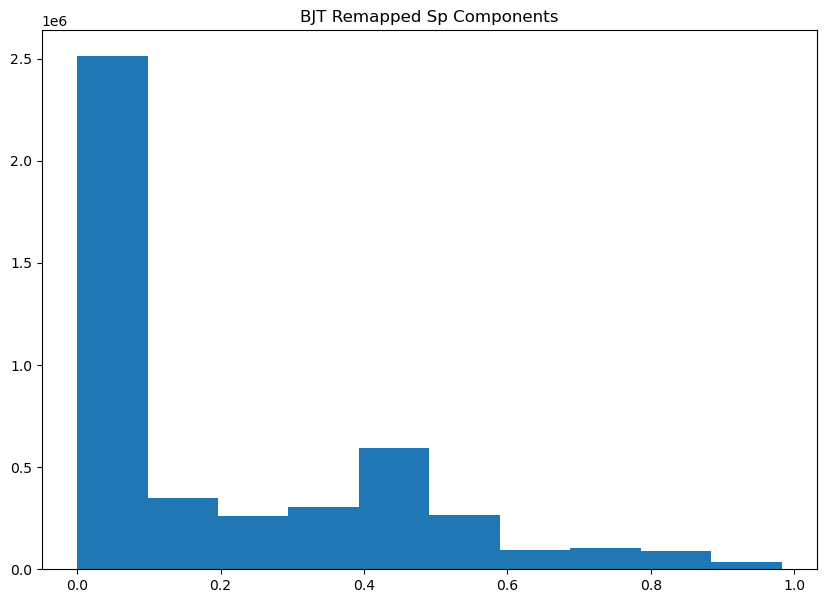

MINIMUM REMAP: 0.0, MAXIMUM: 0.9823750257492065


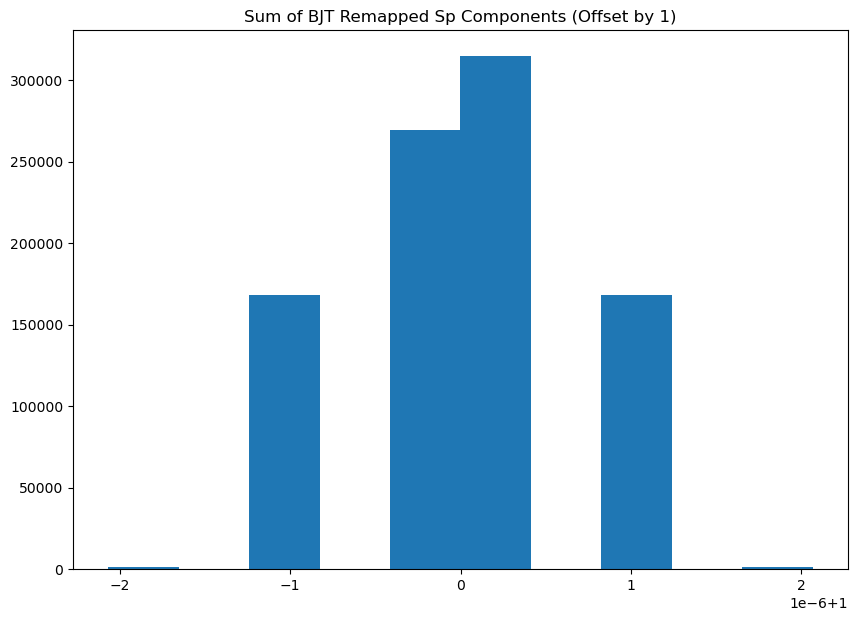

0


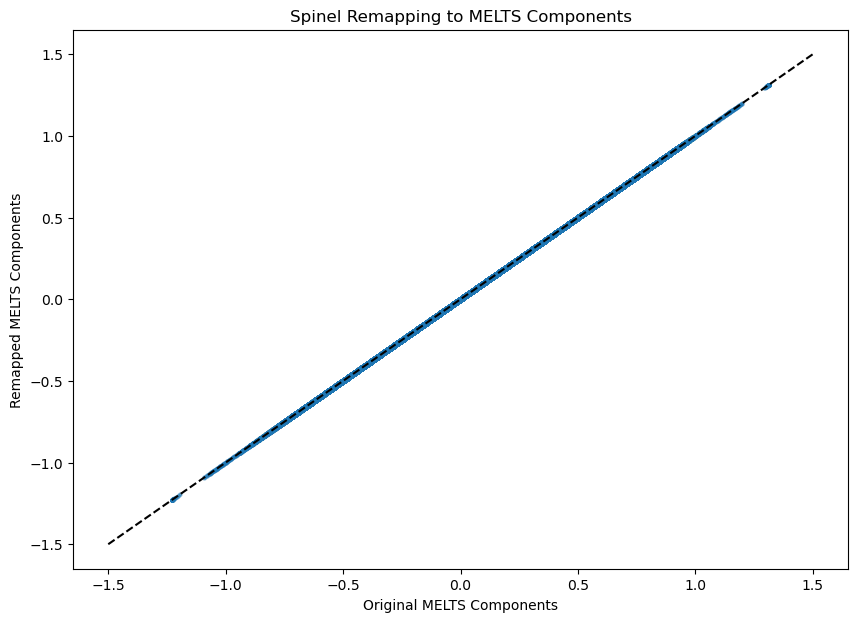

In [ ]:
# Spinel Transformation Tests

Asp = np.array([[  1.00,   0.00,  0.00,  0.00,   0.00],
 [  0.00,   1.00,   0.00,   0.00,   0.00],
 [  0.00,   0.40,   0.60,   0.00,   0.00],
 [  0.00,  0.95,   0.00,   0.05,  0.00],
 [  0.00,   0.2,   0.00,   0.00,  0.8]])
AspInv = np.linalg.inv(Asp)


transformed = sp_components @ Asp
retransformed = transformed @ AspInv

print(np.array2string(Asp, formatter={'float_kind':lambda x: f"{x:6.2f}"}))
print(np.array2string(AspInv, formatter={'float_kind':lambda x: f"{x:6.2f}"}))

#print(transformed.sum(axis=1))
plt.hist((transformed).flatten())#, bins = [-0.2,0,0.2,0.4,0.6,0.8,1.0])
plt.title('BJT Remapped Sp Components')
plt.savefig('BJTSpRemapedComps.png')

plt.show()

print(f"MINIMUM REMAP: {np.min(transformed)}, MAXIMUM: {np.max(transformed)}")

plt.hist((transformed).sum(axis=1))
plt.title('Sum of BJT Remapped Sp Components (Offset by 1)')
plt.savefig('BJTSpRemapSums.png')
plt.show()
print((transformed > 1).sum() + (transformed < 0).sum())

plt.plot([-1.5,1.5],[-1.5,1.5], linestyle = '--', color = 'black')
plt.scatter(sp_components, retransformed, s= 5, alpha = 0.4)
#plt.scatter(sp_components[np.where(wrong_comps)[0]], retransformed[np.where(wrong_comps)[0]], s = 7, alpha = 0.7, marker = 'x', color = 'red')
plt.title('Spinel Remapping to MELTS Components')
plt.xlabel('Original MELTS Components')
plt.ylabel('Remapped MELTS Components')
plt.savefig('BJTrecastedSP.png')

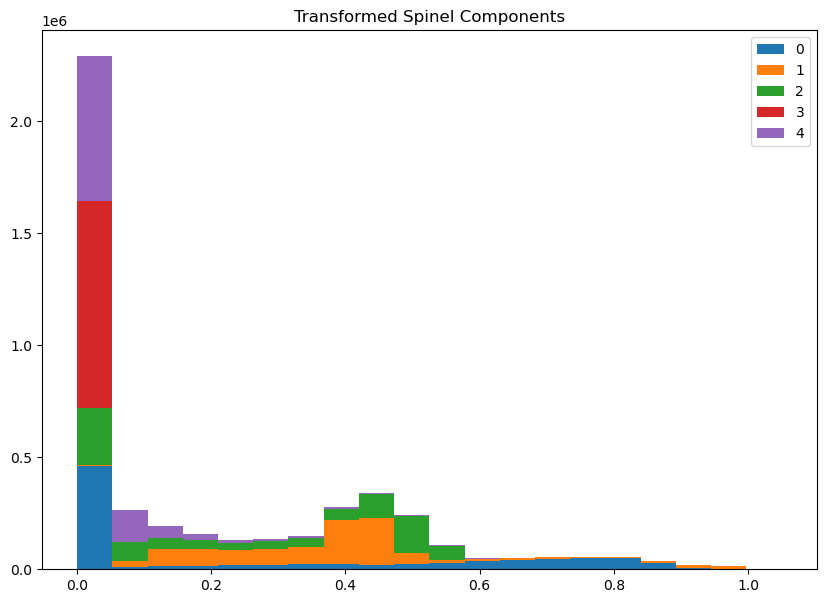

In [20]:
plt.hist([transformed[:,c] for c in np.arange(transformed.shape[1])],stacked=True,bins = np.linspace(0,1.05,21), label=np.arange(transformed.shape[1]))
plt.legend()
plt.title('Transformed Spinel Components')
plt.savefig('RecastSpHistogram.png')

In [4]:
nphases

20

In [6]:
len(mass_indices)

21